In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = "/content/scores_data.csv"
df = pd.read_csv(file_path)

In [3]:
print("Dataset Preview:")
print(df.head())

Dataset Preview:
       Batch  User_ID     Score   
0  AI_ELITE_7  uid_149       6 / 7
1  AI_ELITE_7  uid_148       6 / 7
2  AI_ELITE_7  uid_147       7 / 7
3  AI_ELITE_7  uid_146       7 / 7
4  AI_ELITE_7  uid_145       4 / 7


In [5]:
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Batch        149 non-null    object
 1   User_ID      149 non-null    object
 2      Score     149 non-null    object
dtypes: object(3)
memory usage: 3.6+ KB
None


In [9]:
df.columns = df.columns.str.strip()
df["Batch"]

,Batch
0,AI_ELITE_7
1,AI_ELITE_7
2,AI_ELITE_7
3,AI_ELITE_7
4,AI_ELITE_7
...,...
144,AI_ELITE_4
145,AI_ELITE_4
146,AI_ELITE_4
147,AI_ELITE_4


In [10]:
print("Unique Batches:", df['Batch'].unique())
print("Score Range:", df['Score'].min(), "to", df['Score'].max())

Unique Batches: ['AI_ELITE_7' 'AI_ELITE_6' 'AI_ELITE_4']
Score Range: 0 / 7 to 7 / 7


In [12]:
df['Score'] = df['Score'].apply(lambda x: int(x.split(' / ')[0]))
batch_stats = df.groupby('Batch')['Score'].agg(
    Students_Count='count',
    Average_Score='mean',
    Median_Score='median',
    Min_Score='min',
    Max_Score='max',
    Std_Deviation='std'
).reset_index()

In [13]:
print("Batch-wise Statistics:")
print(batch_stats)

Batch-wise Statistics:
        Batch  Students_Count  Average_Score  Median_Score  Min_Score  \
0  AI_ELITE_4              48       3.791667           4.0          0   
1  AI_ELITE_6              48       4.229167           4.0          0   
2  AI_ELITE_7              53       5.056604           5.0          2   

   Max_Score  Std_Deviation  
0          7       1.443376  
1          7       1.640441  
2          7       1.446682  


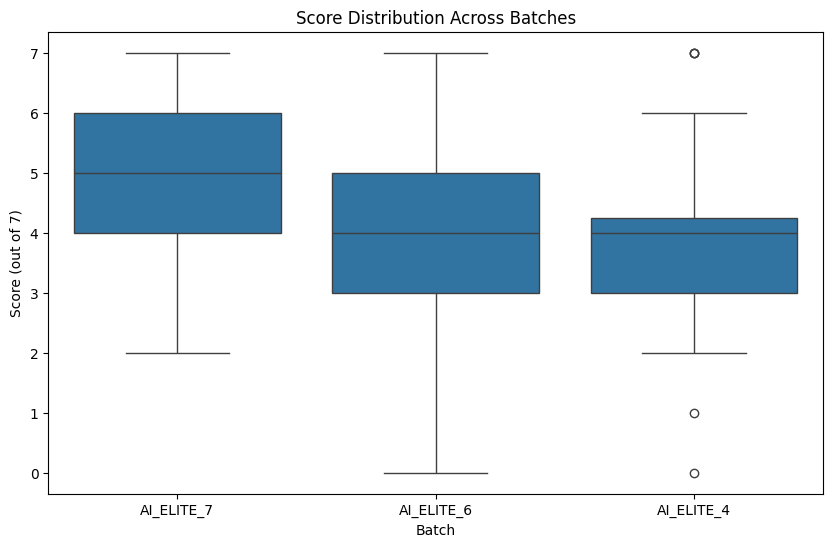

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Batch', y='Score', data=df)
plt.title("Score Distribution Across Batches")
plt.ylabel("Score (out of 7)")
plt.xlabel("Batch")
plt.show()

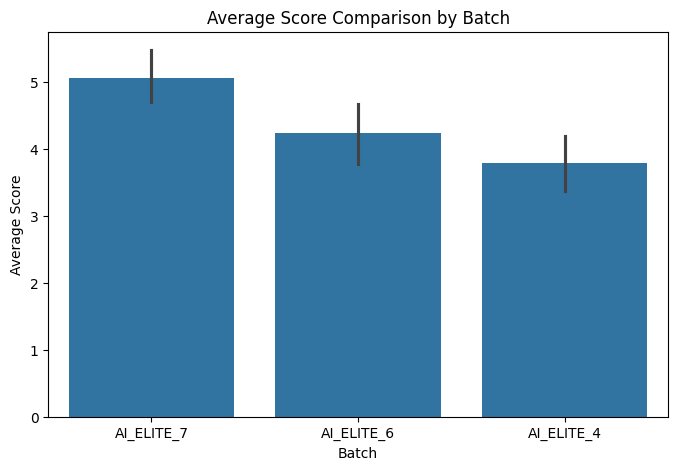

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Batch', y='Score', data=df, estimator='mean')
plt.title("Average Score Comparison by Batch")
plt.ylabel("Average Score")
plt.xlabel("Batch")
plt.show()

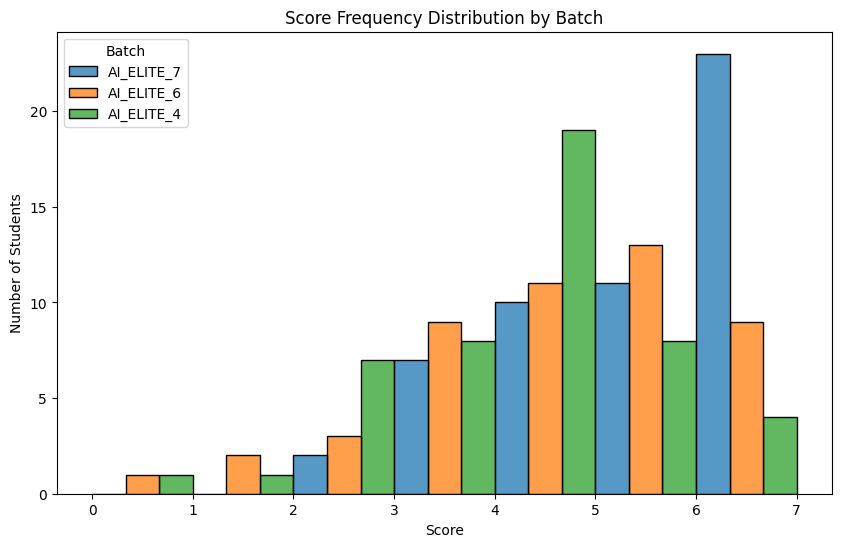

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Score', hue='Batch', bins=7, multiple='dodge')
plt.title("Score Frequency Distribution by Batch")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.show()

In [17]:
top_performers = df[df['Score'] == df['Score'].max()]
low_performers = df[df['Score'] == df['Score'].min()]

In [18]:
print("\nTop Performers:")
print(top_performers)


Top Performers:
          Batch  User_ID  Score
2    AI_ELITE_7  uid_147      7
3    AI_ELITE_7  uid_146      7
5    AI_ELITE_7  uid_144      7
7    AI_ELITE_7  uid_142      7
15   AI_ELITE_7  uid_134      7
16   AI_ELITE_7  uid_133      7
17   AI_ELITE_7  uid_132      7
19   AI_ELITE_7  uid_130      7
24   AI_ELITE_7  uid_125      7
35   AI_ELITE_7  uid_114      7
63   AI_ELITE_6   uid_86      7
67   AI_ELITE_6   uid_82      7
74   AI_ELITE_6   uid_75      7
78   AI_ELITE_6   uid_71      7
98   AI_ELITE_6   uid_51      7
101  AI_ELITE_4   uid_48      7
105  AI_ELITE_4   uid_44      7
139  AI_ELITE_4   uid_10      7


In [19]:
print("\nLow Performers:")
print(low_performers)


Low Performers:
          Batch User_ID  Score
68   AI_ELITE_6  uid_81      0
135  AI_ELITE_4  uid_14      0


In [20]:
best_batch = batch_stats.loc[batch_stats['Average_Score'].idxmax(), 'Batch']
worst_batch = batch_stats.loc[batch_stats['Average_Score'].idxmin(), 'Batch']

In [21]:
print("\nKey Insights:")
print(f"- Best performing batch (highest average score): {best_batch}")
print(f"- Lowest performing batch (lowest average score): {worst_batch}")
print("- Higher standard deviation indicates inconsistent performance")
print("- Boxplot highlights score spread and outliers per batch")


Key Insights:
- Best performing batch (highest average score): AI_ELITE_7
- Lowest performing batch (lowest average score): AI_ELITE_4
- Higher standard deviation indicates inconsistent performance
- Boxplot highlights score spread and outliers per batch
